In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df=pd.read_csv("/content/house_price_regression_dataset.csv")
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [11]:
X=df[['Square_Footage']]
y=df['House_Price']

In [12]:
X

,Square_Footage
0,1360
1,4272
2,3592
3,966
4,4926
...,...
995,3261
996,3179
997,2606
998,4723


In [13]:
y

,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06
...,...
995,7.014940e+05
996,6.837232e+05
997,5.720240e+05
998,9.648653e+05


In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=45)

In [31]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()

In [32]:
reg.fit(X_train,y_train)

LinearRegression()

In [33]:
y_pred=reg.predict(X_train)

In [34]:
from sklearn.metrics import r2_score
print(r2_score(y_train,y_pred)*100)

98.2427495353913


In [35]:
X_train=X_train.to_numpy().ravel()

In [36]:
training_data=pd.DataFrame({"X_train":X_train,
                            "y_train":y_train,
                            "y_pred":y_pred})
training_data

,X_train,y_train,y_pred
640,1166,319601.391540,289744.977922
357,2641,621862.765418,585106.515663
596,888,215993.895116,234076.837249
833,3728,816939.587431,802772.950594
896,1036,238220.484545,263713.113579
...,...,...,...
544,4636,985351.023913,984595.510776
892,701,246717.966366,196631.001617
643,2469,583183.430910,550664.356685
414,3848,841676.014084,826802.363834


In [24]:
X_test=X_test.to_numpy().ravel()

In [25]:
testing_data=pd.DataFrame({"X_test":X_test,
                           "y_test":y_test})
testing_data

,X_test,y_test
726,967,240302.219971
243,725,165242.297852
342,4172,894611.078656
976,3656,856066.300534
919,841,238047.592800
...,...,...
701,2475,594005.006523
491,4102,838955.453899
48,534,187508.585312
651,2468,540221.253942


In [27]:
from sklearn.metrics import r2_score,root_mean_squared_error
print(f"Training Data Accuracy:{r2_score(y_train,y_pred)*100}")
print(f"Training Data Loss:{root_mean_squared_error(y_train,y_pred)}")

Training Data Accuracy:98.2427495353913
Training Data Loss:33321.14824358949


In [37]:
y_test_pred=reg.predict(X_test)
testing_data["y_test_pred"]=y_test_pred
testing_data

,X_test,y_test,y_test_pred
726,967,240302.219971,249896.200966
243,725,165242.297852,201436.884265
342,4172,894611.078656,891681.779582
976,3656,856066.300534,788355.302650
919,841,238047.592800,224665.317064
...,...,...,...
701,2475,594005.006523,551865.827347
491,4102,838955.453899,877664.621859
48,534,187508.585312,163190.068192
651,2468,540221.253942,550464.111575


In [39]:
from sklearn.metrics import r2_score,root_mean_squared_error
print(f"Testing Data Accuracy:{r2_score(y_test,y_test_pred)*100}")
print(f"Testing Data Loss:{root_mean_squared_error(y_test,y_test_pred)}")

Testing Data Accuracy:98.29040550342458
Testing Data Loss:33757.046513580586


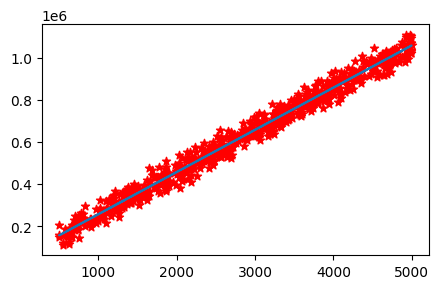

In [41]:
plt.figure(figsize=(5,3))
plt.scatter(x=X_train,y=y_train,color='r',marker='*')
plt.plot(X_train,y_pred)
plt.show()

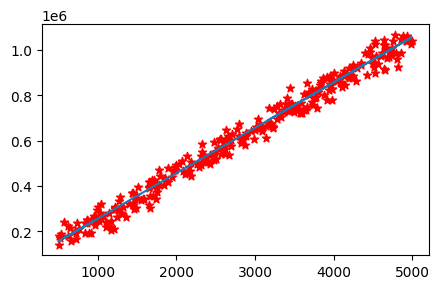

In [43]:
plt.figure(figsize=(5,3))
plt.scatter(x=X_test,y=y_test,color='r',marker='*')
plt.plot(X_test,y_test_pred)
plt.show()